## EDA DE DATA


## Import des libries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


## exploration des données

In [6]:
df = pd.read_csv("Dataset.csv")
display(df)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## exploration des donnes

In [ ]:
print("Dimensions :", df.shape)
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## types et stucture

In [ ]:
df.info()
##df.types


## Premier observation

In [ ]:
display(df.head())

###  les missing values and duplicates

### Descriptive statistics

In [ ]:
display(df.describe().round(2))
display(df.describe(include="object"))

###  Analyse technique des variables

In [ ]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print("\nLignes dupliquees :", df.duplicated().sum())

## Classification des variables

## les  Quantitatives(numeriques)

In [ ]:
numeric_col=df.select_dtypes(include='number').columns.tolist()

print(numeric_col)
##Quantitatives : duration, days_left,prix(cible)


['Unnamed: 0', 'duration', 'days_left', 'price']


## Categorials columns

In [ ]:
categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
##continous:airline,source_city,depature_time,stops,arrival_time,destination_city,class


['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


## Analyse univariee

## Variables categorielles

In [9]:
df['airline'].value_counts()


categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
print(categorical_cols)

categorical_cols=['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
for col in categorical_cols:
    print(f"\n {col} ")
    effectifs = df[col].value_counts()
    pourcentages = (df[col].value_counts(normalize=True) * 100).round(2)
    print(pd.DataFrame({"effectif": effectifs, "pourcentage": pourcentages}))


lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True) * 100
    lignes.append({
        "variable": col,
        "nb_modalites": p.size,
        "dominante": p.idxmax(),
        "part_dominante_%": round(p.max(), 1),
        "plus_rare": p.idxmin(),
        "part_rare_%": round(p.min(), 1),
        "dominante/rare": round(p.max() / p.min(), 1),
        
    })
resume = pd.DataFrame(lignes).set_index("variable")


print(resume)



['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

 airline 
           effectif  pourcentage
airline                         
Vistara      127859        42.60
Air_India     80892        26.95
Indigo        43120        14.37
GO_FIRST      23173         7.72
AirAsia       16098         5.36
SpiceJet       9011         3.00

 source_city 
             effectif  pourcentage
source_city                       
Delhi           61343        20.44
Mumbai          60896        20.29
Bangalore       52061        17.34
Kolkata         46347        15.44
Hyderabad       40806        13.60
Chennai         38700        12.89

 departure_time 
                effectif  pourcentage
departure_time                       
Morning            71146        23.70
Early_Morning      66790        22.25
Evening            65102        21.69
Night              48015        16.00
Afternoon          47794        15.92
Late_Night          1306         0.44

## Visualisation de variables categories

## destination  city

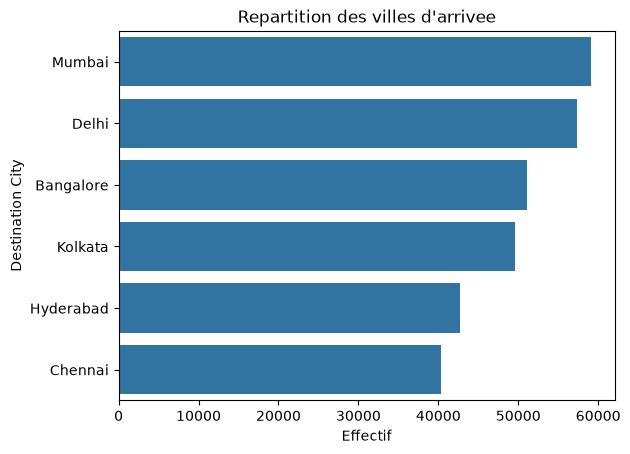

In [10]:

sns.countplot(
    data=df,
    y="destination_city",
    order=df["destination_city"].value_counts().index
)

plt.title("Repartition des villes d'arrivee")
plt.xlabel("Effectif")
plt.ylabel("Destination City")

plt.show()

## Source cITY

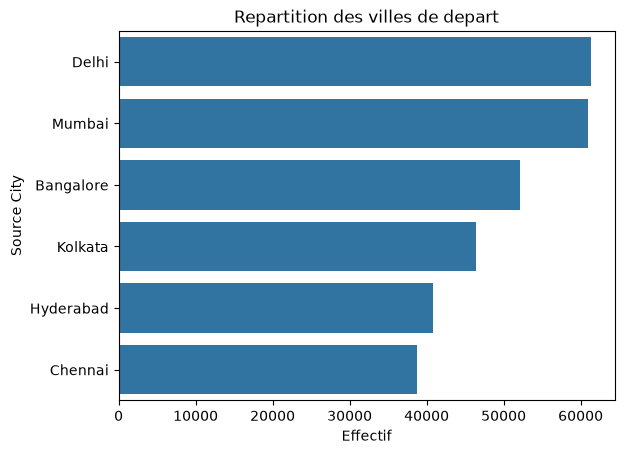

In [11]:

sns.countplot(
    data=df,
    y="source_city",
    order=df["source_city"].value_counts().index
)

plt.title("Repartition des villes de depart")
plt.xlabel("Effectif")
plt.ylabel("Source City")

plt.show()

## Airline

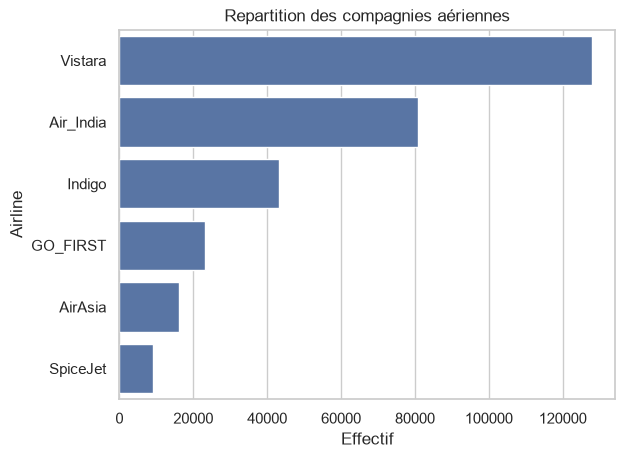

In [12]:


sns.set_theme(style="whitegrid")

sns.countplot(
    data=df,
    y="airline",
    order=df["airline"].value_counts().index
)

plt.title("Repartition des compagnies aériennes")
plt.xlabel("Effectif")
plt.ylabel("Airline")

plt.show()

###  variables quantitatives()


In [15]:
categorial = df[["airline", "flight", "source_city", "destination_city", "class", "stops", "arrival_time", "departure_time"]]
ordinal = df[["class", "stops", "arrival_time", "departure_time"]] 
quantitative = df[[ "duration", "days_left", "price"]] 
cible = [] 

print(categorial.head()) 

print(ordinal.head())


print(quantitative.head()) 
print(categorial.describe())

print(ordinal.describe())

print(quantitative.describe())  



    airline   flight source_city destination_city    class stops  \
0  SpiceJet  SG-8709       Delhi           Mumbai  Economy  zero   
1  SpiceJet  SG-8157       Delhi           Mumbai  Economy  zero   
2   AirAsia   I5-764       Delhi           Mumbai  Economy  zero   
3   Vistara   UK-995       Delhi           Mumbai  Economy  zero   
4   Vistara   UK-963       Delhi           Mumbai  Economy  zero   

    arrival_time departure_time  
0          Night        Evening  
1        Morning  Early_Morning  
2  Early_Morning  Early_Morning  
3      Afternoon        Morning  
4        Morning        Morning  
     class stops   arrival_time departure_time
0  Economy  zero          Night        Evening
1  Economy  zero        Morning  Early_Morning
2  Economy  zero  Early_Morning  Early_Morning
3  Economy  zero      Afternoon        Morning
4  Economy  zero        Morning        Morning
   duration  days_left  price
0      2.17          1   5953
1      2.33          1   5953
2      2.17    

##  Analyse technique des variables

In [ ]:

numerical_cols = ["duration", "days_left", "price"]
categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
ordinal_cols = ["stops", "class"] 


all_cols = list(df.columns)





###  recapitulatif des variables


##  Analyse univariée

### Variables catégorielles

In [ ]:

for col in categorical_cols:
    vc = df[col].value_counts()
    vp = df[col].value_counts(normalize=True) * 100
    res = pd.DataFrame({"effectif": vc, "pourcentage": vp.round(2)})
    res = res.sort_values("effectif", ascending=False)
    print(f"=== {col} ===")
    display(res)


#### Interpretation
- Observation : Les

### Repartitions (barres)

In [ ]:

nominal_cols = ["airline", "source_city", "destination_city"]
for col in nominal_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f"Répartition de {col}")
    plt.xlabel("Effectif")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


#### Interprétation
- Observation : Les diagrammes

In [ ]:

orders = {
  "stops": ["zero", "one", "two_or_more"],
  "class": ["Economy", "Business"],
  "departure_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
  "arrival_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
}
for col in ["stops", "class", "departure_time", "arrival_time"]:
    plt.figure(figsize=(8,4))
    order = orders.get(col, df[col].value_counts().index)
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Repartition de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()


#### Interpretation
- Observation : 

### Categories dominantes

In [20]:

categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True)*100
    lignes.append({
        "variable": col,
        "nb_modalites": int(p.size),
        "dominante": p.idxmax(),
        "part_dominante_%": round(float(p.max()), 2),
        "plus_rare": p.idxmin(),
        "part_rare_%": round(float(p.min()), 2),
    })
dom = pd.DataFrame(lignes).set_index("variable")
display(dom)


,nb_modalites,dominante,part_dominante_%,plus_rare,part_rare_%
variable,,,,,
airline,6,Vistara,42.60,SpiceJet,3.00
source_city,6,Delhi,20.44,Chennai,12.89
departure_time,6,Morning,23.70,Late_Night,0.44
stops,3,one,83.58,two_or_more,4.43
arrival_time,6,Night,30.50,Late_Night,4.66
destination_city,6,Mumbai,19.69,Chennai,13.45
class,2,Economy,68.85,Business,31.15


#### Interpretation
- Observation : 


### Desequilibres

In [21]:

categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True)*100
    ratio = p.max() / p.min() if p.min() > 0 else float('inf')
    if ratio < 2:
        qual = "faible (< 2)"
    elif ratio < 10:
        qual = "modere (>=2 et < 10)"
    else:
        qual = "fort (>= 10)"
    lignes.append({
        "variable": col,
        "part_dominante_%": round(float(p.max()), 2),
        "part_rare_%": round(float(p.min()), 2),
        "ratio_dom_rare": round(float(ratio), 2),
        "qualification": qual,
    })
bal = pd.DataFrame(lignes).set_index("variable")
display(bal)


,part_dominante_%,part_rare_%,ratio_dom_rare,qualification
variable,,,,
airline,42.60,3.00,14.19,fort (>= 10)
source_city,20.44,12.89,1.59,faible (< 2)
departure_time,23.70,0.44,54.48,fort (>= 10)
stops,83.58,4.43,18.88,fort (>= 10)
arrival_time,30.50,4.66,6.54,modere (>=2 et < 10)
destination_city,19.69,13.45,1.46,faible (< 2)
class,68.85,31.15,2.21,modere (>=2 et < 10)


#### Interpretation
- Observation : 

### Variables quantitatives

### Statistiques descriptives

In [ ]:

res_list = []
for col in numerical_cols:
    s = df[col].describe()
    serie = df[col]
    var = serie.var(ddof=1)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    cv = (serie.std(ddof=1) / serie.mean()) if serie.mean() != 0 else float('nan')
    res_list.append({
        "variable": col,
        "count": int(s["count"]),
        "mean": round(float(s["mean"]), 4),
        "std": round(float(s["std"]), 4),
        "min": round(float(s["min"]), 4),
        "25%": round(float(s["25%"]), 4),
        "50%": round(float(s["50%"]), 4),
        "75%": round(float(s["75%"]), 4),
        "max": round(float(s["max"]), 4),
        "variance": round(float(var), 4),
        "IQR": round(float(iqr), 4),
        "CV": round(float(cv), 4),
    })
stats_q = pd.DataFrame(res_list).set_index("variable")
display(stats_q)


#### Interpretation
- Observation : Les statistiques (moyenne, médiane, écart-type, min/max, variance, IQR, CV) sont présentées avec leurs valeurs exactes calculées sur l'ensemble.

### Distributions

In [ ]:

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=60, stat="density")
    m = df[col].mean()
    med = df[col].median()
    plt.axvline(m, color='red', linestyle='--', label=f'Moyenne={m:.2f}')
    plt.axvline(med, color='green', linestyle='-', label=f'Médiane={med:.2f}')
    plt.legend()
    plt.title(f"Distribution de {col} (histogramme + KDE)")
    plt.xlabel(col)
    plt.ylabel("Densité")
    plt.tight_layout()
    plt.show()


#### Interprétation
- Observation : Pour chaque variable quantitative, l'histogramme avec 

### Dispersion

#### Interpretation
- Observation : L'écart-type, 

### Valeurs extremes

In [ ]:

out_rows = []
for col in numerical_cols:
    s = df[col]
    q1 = s.quantile(0.25); q3 = s.quantile(0.75); iqr = q3-q1
    inf = q1 - 1.5*iqr; sup = q3 + 1.5*iqr
    n_low = (s < inf).sum(); n_high = (s > sup).sum(); n_tot = n_low + n_high
    out_rows.append({
        "variable": col,
        "q1": round(float(q1),4),
        "q3": round(float(q3),4),
        "IQR": round(float(iqr),4),
        "borne_inf_Tukey": round(float(inf),4),
        "borne_sup_Tukey": round(float(sup),4),
        "nb_outliers_inf": int(n_low),
        "nb_outliers_sup": int(n_high),
        "nb_outliers_total": int(n_tot),
        "%_outliers": round(float(100*n_tot/len(df)), 4) if len(df)>0 else 0
    })
out_df = pd.DataFrame(out_rows).set_index("variable")
display(out_df)

# Boxplots
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col} (règle Tukey 1.5×IQR)")
    plt.tight_layout()
    plt.show()


#### Interpretation
- Observation : Pour chaque variable quantitative, le nombre d'outliers détectés par la

### Asymetrie

In [ ]:

from scipy.stats import skew
sk_list = []
for col in numerical_cols:
    skv = skew(df[col], nan_policy='omit')
    if skv > 0.1:
        comm = "asymétrie à droite (positive)"
    elif skv < -0.1:
        comm = "asymétrie à gauche (négative)"
    else:
        comm = "proche de symétrique (aucune asymétrie marquée)"
    sk_list.append({
        "variable": col,
        "skewness": round(float(skv), 4),
        "commentaire": comm
    })
sk_df = pd.DataFrame(sk_list).set_index("variable")
display(sk_df)


ModuleNotFoundError: No module named 'scipy'

#### Interpretation


##  Analyse multivariee

### Durée du vol et prix

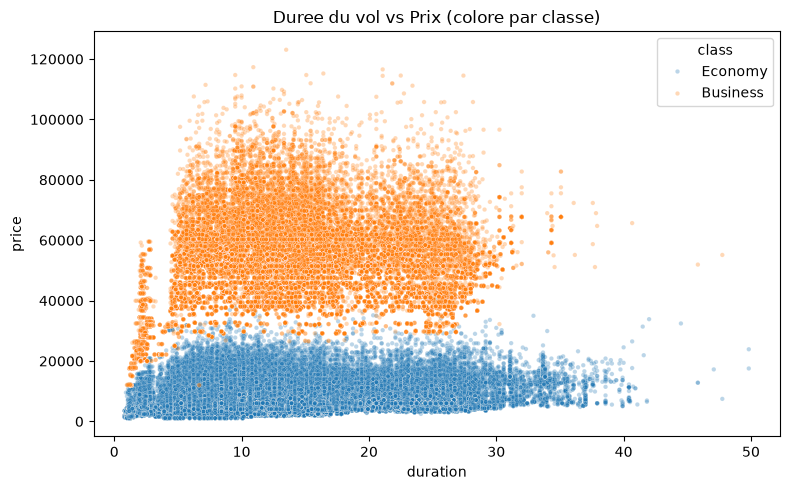

Corrélation de Pearson (globale) duration-price : 0.2042
Corrélation de Pearson (class=Economy) duration-price : 0.2884
Corrélation de Pearson (class=Business) duration-price : 0.2427


In [ ]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="duration", y="price", hue="class", alpha=0.3, s=10)
plt.title("Duree du vol vs Prix (colore par classe)")
plt.xlabel("duration")
plt.ylabel("price")
plt.tight_layout()
plt.show()

# Corrélation globale
corr_glob = df[["duration","price"]].corr(method="pearson").iloc[0,1]
print(f"Corrélation de Pearson (globale) duration-price : {corr_glob:.4f}")


for c in df["class"].dropna().unique():
    sub = df[df["class"]==c]
    if len(sub)>=2:
        corr_c = sub[["duration","price"]].corr(method="pearson").iloc[0,1]
        print(f"Corrélation de Pearson (class={c}) duration-price : {corr_c:.4f}")


### Compagnie aerienne et prix

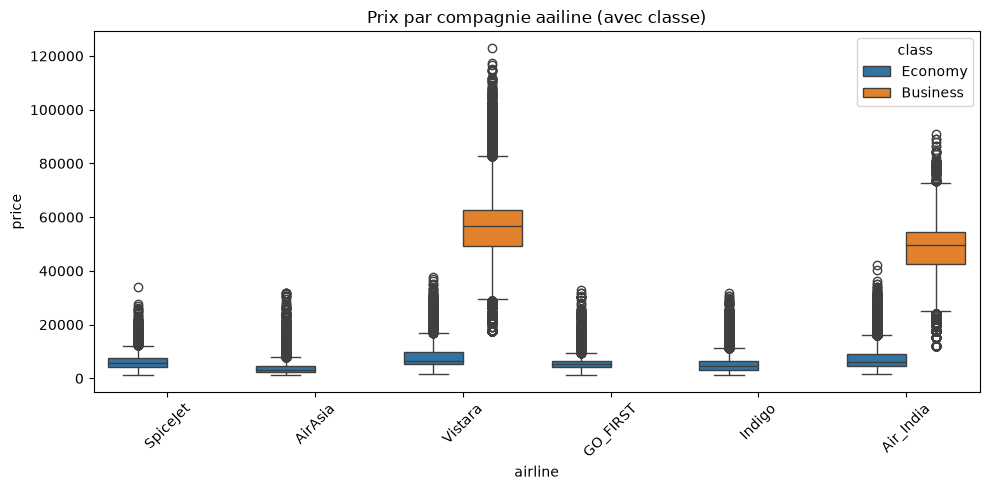

In [ ]:

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="airline", y="price", hue="class")
plt.title("Prix par compagnie aailine (avec classe)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# # Comparer les compagnies UNIQUEMENT en Economy
# eco = df[df["class"] == "Economy"]
# plt.figure(figsize=(8, 4))
# sns.boxplot(data=eco, x="airline", y="price", color="steelblue",
#             order=eco.groupby("airline")["price"].median().sort_values().index)
# plt.title("Prix par compagnie — Economy uniquement")
# plt.xticks(rotation=30)
# plt.show()

# # Vérifier quelles compagnies vendent quelle classe
# print(pd.crosstab(df["airline"], df["class"]))


### Nombre d'escales et prix

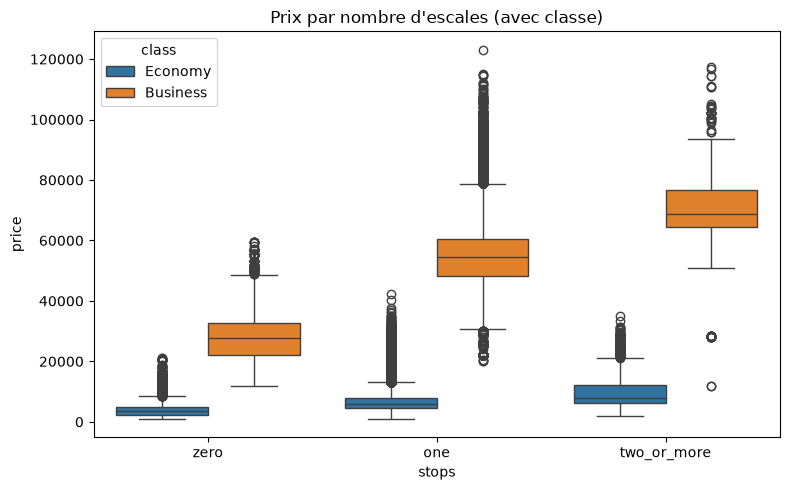

In [ ]:

order_stops = ["zero", "one", "two_or_more"]
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="stops", y="price", hue="class", order=order_stops)
plt.title("Prix par nombre d'escales (avec classe)")
plt.tight_layout()
plt.show()


### Nombre de jours avant le vol et prix

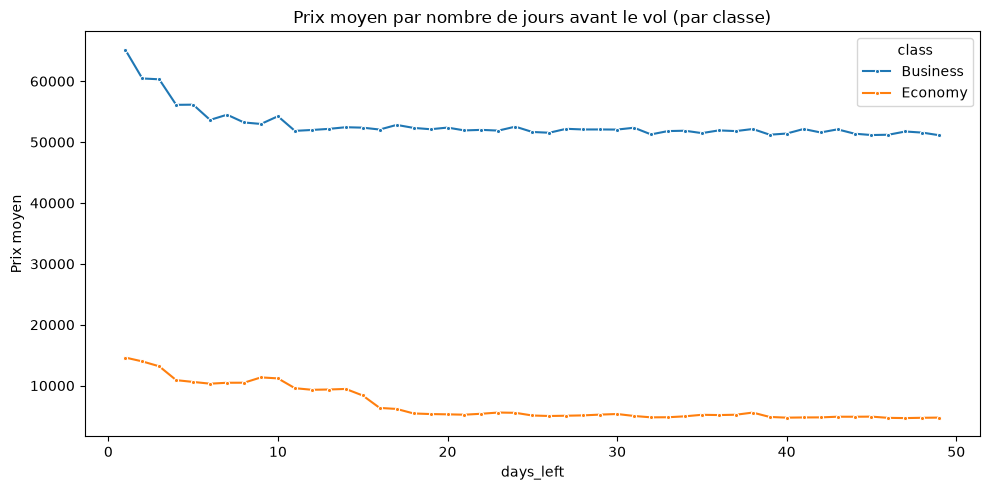

In [ ]:


mean_price = df.groupby(["days_left", "class"])["price"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=mean_price, x="days_left", y="price", hue="class", marker="o", markersize=3)
plt.title("Prix moyen par nombre de jours avant le vol (par classe)")
plt.xlabel("days_left")
plt.ylabel("Prix moyen")
plt.tight_layout()
plt.show()


## Preprocessing

## traitement des valeurs manquantes

In [22]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Observation: 
on a pas  des des valeurs manquantes

### transformation des variables ordinales

In [24]:
import pandas as pd

df = pd.read_csv("Dataset.csv")
df_copy = df.copy()          

mapping_stops = {"zero": 0, "one": 1, "two_or_more": 2}
mapping_class = {"Economy": 0, "Business": 1}

colonnes_ordinales_std = ["stops", "class"]
mappings = {
    "stops": mapping_stops,
    "class": mapping_class,
}
for col in colonnes_ordinales_std:
    df_copy[col + "_encoded"] = df_copy[col].map(mappings[col])

print(df_copy.dtypes)

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
stops_encoded         int64
class_encoded         int64
dtype: object


## encoding variables  nominales

In [ ]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ["airline", "source_city", "destination_city", "departure_time", "arrival_time"]


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')


ohe_transform = ohe.fit_transform(df_copy[nominal_cols])


df_copy = pd.concat([df_copy, ohe_transform], axis=1).drop(columns=nominal_cols)


KeyError: "None of [Index(['airline', 'source_city', 'destination_city', 'departure_time',\n       'arrival_time'],\n      dtype='str')] are in the [columns]"

In [25]:
display(df_copy)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,stops_encoded,class_encoded
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0,0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0,0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0,0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0,0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,1,1
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,1,1
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,1,1
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,1,1


## Supprimer les colonnes originales (Ordinales)

In [38]:
df_encoded = df_copy.drop(columns=["stops", "class"])

print(df_copy.columns.tolist())
print(df_copy.dtypes)


['stops', 'class', 'duration', 'days_left', 'price', 'stops_encoded', 'class_encoded', 'airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Bangalore', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Afternoon', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Afternoon', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']
stops                               str
class                               str
duration                        float64
days_left                         int64
price     

In [43]:
colonnes_a_supprimer = ["class", "stops"]

df = df.drop(columns=colonnes_a_supprimer, errors="ignore")
df_copy = df_copy.drop(columns=colonnes_a_supprimer, errors="ignore")



print(df.columns.tolist())
print(df_copy.columns.tolist())
display(df_copy)


['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'duration', 'days_left', 'price']
['duration', 'days_left', 'price', 'stops_encoded', 'class_encoded', 'airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Bangalore', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Afternoon', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Afternoon', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']


,duration,days_left,price,stops_encoded,class_encoded,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,2.17,1,5953,0,0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.33,1,5953,0,0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2.17,1,5956,0,0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2.25,1,5955,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2.33,1,5955,0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,10.08,49,69265,1,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
300149,10.42,49,77105,1,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
300150,13.83,49,79099,1,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
300151,10.00,49,81585,1,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Separrer   features et cible :price

In [45]:
X = df_copy.drop(columns=["price"])
y = df_copy["price"]

print("X :", X.shape)
print("y :", y.shape)
print(X.columns.tolist())

X : (300153, 34)
y : (300153,)
['duration', 'days_left', 'stops_encoded', 'class_encoded', 'airline_AirAsia', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore', 'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata', 'source_city_Mumbai', 'destination_city_Bangalore', 'destination_city_Chennai', 'destination_city_Delhi', 'destination_city_Hyderabad', 'destination_city_Kolkata', 'destination_city_Mumbai', 'departure_time_Afternoon', 'departure_time_Early_Morning', 'departure_time_Evening', 'departure_time_Late_Night', 'departure_time_Morning', 'departure_time_Night', 'arrival_time_Afternoon', 'arrival_time_Early_Morning', 'arrival_time_Evening', 'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night']


## Le split Train/Test

In [ ]:
from  sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# print("X train :",X_train.shape)
# print("X_test:",X_test.shape)
# print("y_train :", y_train.shape)
# print("y_test  :", y_test.shape)
print(X_train.dtypes)


duration                        float64
days_left                         int64
stops_encoded                     int64
class_encoded                     int64
airline_AirAsia                 float64
airline_Air_India               float64
airline_GO_FIRST                float64
airline_Indigo                  float64
airline_SpiceJet                float64
airline_Vistara                 float64
source_city_Bangalore           float64
source_city_Chennai             float64
source_city_Delhi               float64
source_city_Hyderabad           float64
source_city_Kolkata             float64
source_city_Mumbai              float64
destination_city_Bangalore      float64
destination_city_Chennai        float64
destination_city_Delhi          float64
destination_city_Hyderabad      float64
destination_city_Kolkata        float64
destination_city_Mumbai         float64
departure_time_Afternoon        float64
departure_time_Early_Morning    float64
departure_time_Evening          float64


## Modelisation

### RandomForestRegression

## Linear Regression

In [ ]:



numeric_cols = ["duration", "days_left"]
ordinal_cols = ["stops", "class"]
nominal_cols = ["airline", "source_city", "destination_city", "departure_time", "arrival_time"]

ordinal_categories = [
    ["zero", "one", "two_or_more"],
    ["Economy", "Business"],
]


preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])


pipe = Pipeline([
    ("transformer", preprocess),
    ("model", LinearRegression()),
])


pipe.fit(X_train, y_train)


y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.1f}")
print(f"RMSE = {rmse:.1f}")
print(f"R²   = {r2:.3f}")

NameError: name 'ColumnTransformer' is not defined